# Tutorial 8: Train NicheTrans on human lymph node data

In [25]:
import os, time, datetime, warnings

import torch
import torch.nn as nn
from torch.optim import lr_scheduler

from model.nicheTrans_img import *
from datasets.data_manager_human_lymph_node import Lymph_node

from utils.utils import *
from utils.utils_training_human_lymph_node import train, test
from utils.utils_dataloader import *

warnings.filterwarnings("ignore")

### Initialize the args and fix seeds

In [26]:
%run ./args/args_human_lymph_node.py
args = args

set_seed(args.seed)
os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu_devices

print("==========\nArgs:{}\n==========".format(args))

Args:Namespace(noise_rate=0.5, dropout_rate=0.1, use_moe_ffn=True, num_experts=2, moe_gate_hidden_dim=256, moe_gate_type='softmax', ffn_mult=2, n_source=3000, workers=4, adata_path='/mnt/datadisk0/Processed_DATA/2024_nm_human_lymph_nodes/', max_epoch=20, stepsize=10, train_batch=32, test_batch=32, optimizer='adam', lr=0.0003, gamma=0.1, weight_decay=0.0005, seed=1, save_dir='./log', eval_step=1, gpu_devices='0')


### Initialize dataloaders and NicheTrans

In [27]:
# create the dataloaders
dataset = Lymph_node(adata_path=args.adata_path, n_top_genes=args.n_source)
trainloader, testloader = human_node_dataloader(args, dataset)

# create the model
source_dimension, target_dimension = dataset.rna_length, dataset.protein_length
model = NicheTrans(source_length=source_dimension, target_length=target_dimension, noise_rate=args.noise_rate, dropout_rate=args.dropout_rate,num_experts=args.num_experts,moe_gate_hidden_dim=args.moe_gate_hidden_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

------Calculating spatial graph...
The graph contains 13638 edges, 3484 cells.
3.9145 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 27174 edges, 3484 cells.
7.7997 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 13138 edges, 3359 cells.
3.9113 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 26192 edges, 3359 cells.
7.7976 neighbors per cell on average.
=> Human lymph node loaded
Dataset statistics:
  ------------------------------
  subset   | # num | 
  ------------------------------
  train    |  After filting  3484 spots
  test     |  After filting  3359 spots
  ------------------------------


### Initialize loss function (criterion) and optimizer

In [28]:
criterion = nn.MSELoss()

if args.optimizer == 'adam':
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
elif args.optimizer == 'SGD':
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)
else:
    print('unexpected optimizer')

if args.stepsize > 0:
    scheduler = lr_scheduler.StepLR(optimizer, step_size=args.stepsize, gamma=args.gamma)

### Model training and testing

In [29]:
start_time = time.time()

for epoch in range(args.max_epoch):
    last_epoch = epoch + 1 == args.max_epoch

    print("==> Epoch {}/{}".format(epoch+1, args.max_epoch))
    
    ################
    train(model, criterion, optimizer, trainloader, device=device)
    if args.stepsize > 0: scheduler.step()
    ################
    
pearson = test(model, testloader, device=device)
torch.save(model.state_dict(), 'NicheTrans_human_lymph_node_last.pth')

elapsed = round(time.time() - start_time)
elapsed = str(datetime.timedelta(seconds=elapsed))
print("Finished. Total elapsed time (h:m:s): {}".format(elapsed))

==> Epoch 1/20
Batch 108/108	 Loss 1.218842 (0.981506)
==> Epoch 2/20
Batch 108/108	 Loss 0.423999 (0.883947)
==> Epoch 3/20
Batch 108/108	 Loss 0.760838 (0.848547)
==> Epoch 4/20
Batch 108/108	 Loss 4.092101 (0.823282)
==> Epoch 5/20
Batch 108/108	 Loss 1.091248 (0.796591)
==> Epoch 6/20
Batch 108/108	 Loss 0.335681 (0.802858)
==> Epoch 7/20
Batch 108/108	 Loss 1.406589 (0.782563)
==> Epoch 8/20
Batch 108/108	 Loss 0.300708 (0.776552)
==> Epoch 9/20
Batch 108/108	 Loss 0.553702 (0.738102)
==> Epoch 10/20
Batch 108/108	 Loss 0.332580 (0.728740)
==> Epoch 11/20
Batch 108/108	 Loss 1.586906 (0.699986)
==> Epoch 12/20
Batch 108/108	 Loss 0.970491 (0.681879)
==> Epoch 13/20
Batch 108/108	 Loss 1.040636 (0.681834)
==> Epoch 14/20
Batch 108/108	 Loss 2.455512 (0.672605)
==> Epoch 15/20
Batch 108/108	 Loss 0.300646 (0.676618)
==> Epoch 16/20
Batch 108/108	 Loss 0.527207 (0.654912)
==> Epoch 17/20
Batch 108/108	 Loss 0.427220 (0.667728)
==> Epoch 18/20
Batch 108/108	 Loss 0.334955 (0.660170)
=

### Optional MoE Routing Analysis

Run the next cell after training if you want to inspect expert activation, load balance, and spatial specialization.


Overall MoE metrics:
{'num_center_spots': 3359, 'num_experts': 2, 'usage_entropy_normalised': 0.9998826858073241, 'top1_entropy_normalised': 0.5910127692678139, 'effective_expert_count': 1.999837374608327, 'dominant_expert_fraction': 0.506376282494137, 'mean_weight_l1_to_uniform': 0.012752565529489168, 'top1_l1_to_uniform': 0.7147960702590057, 'mean_spot_entropy': 0.6929997812951993, 'std_spot_entropy': 0.00018302109467391038}


,expert,average_activation_weight,top1_selection_frequency
0,0,0.506376,0.857398
1,1,0.493624,0.142602


,slice_id,expert_0_mean_weight,expert_1_mean_weight,expert_0_top1_frequency,expert_1_top1_frequency,num_center_spots,normalised_entropy,top1_normalised_entropy,effective_expert_count,dominant_expert_fraction,mean_weight_l1_to_uniform,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy
0,default,0.506376,0.493624,0.857398,0.142602,3359,0.999883,0.591013,1.999837,0.506376,0.012753,0.714796,0.693,0.000183


,spatial_region,expert_0_mean_weight,expert_1_mean_weight,expert_0_top1_frequency,expert_1_top1_frequency,num_center_spots,normalised_entropy,top1_normalised_entropy,effective_expert_count,dominant_expert_fraction,mean_weight_l1_to_uniform,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy
0,default|x0_y0,0.503784,0.496216,0.731868,0.268132,910,0.999959,0.838771,1.999943,0.503784,0.007567,0.463736,0.693056,0.000151
1,default|x0_y1,0.504581,0.495419,0.796104,0.203896,770,0.999939,0.729652,1.999916,0.504581,0.009162,0.592208,0.693050,0.000146
2,default|x1_y0,0.507963,0.492037,0.927273,0.072727,770,0.999817,0.376020,1.999746,0.507963,0.015926,0.854545,0.692961,0.000204
3,default|x1_y1,0.509148,0.490852,0.975798,0.024202,909,0.999758,0.164426,1.999665,0.509148,0.018297,0.951595,0.692934,0.000192


,sample_id,slice_id,spot_id,x,y,batch_index,batch_spot_index,top1_expert,top1_weight,center_entropy,...,target_22,target_23,target_24,target_25,target_26,target_27,target_28,target_29,target_30,spatial_region
0,14_0,default,14_0,14.0,0.0,51,18,0,0.502488,0.693135,...,0.085699,0.184208,0.332505,1.297080,0.601530,1.003018,0.196651,0.449594,0.986500,default|x0_y0
1,16_0,default,16_0,16.0,0.0,54,13,1,0.500920,0.693146,...,0.112855,-2.057792,-1.299184,0.014043,-0.773163,-0.076710,-2.354436,-0.976474,-0.086805,default|x0_y0
2,18_0,default,18_0,18.0,0.0,10,14,1,0.503771,0.693119,...,0.759769,0.193185,0.750456,0.657912,0.422595,0.727902,-0.004481,0.175593,0.472729,default|x0_y0
3,20_0,default,20_0,20.0,0.0,2,15,1,0.504188,0.693112,...,0.572739,-0.263944,0.233377,0.120309,0.369121,-1.205086,0.073081,-0.042643,0.270023,default|x0_y0
4,22_0,default,22_0,22.0,0.0,95,7,1,0.503599,0.693121,...,0.400436,0.213515,0.246174,0.393011,0.127433,0.046691,0.188135,0.327717,0.254237,default|x0_y0


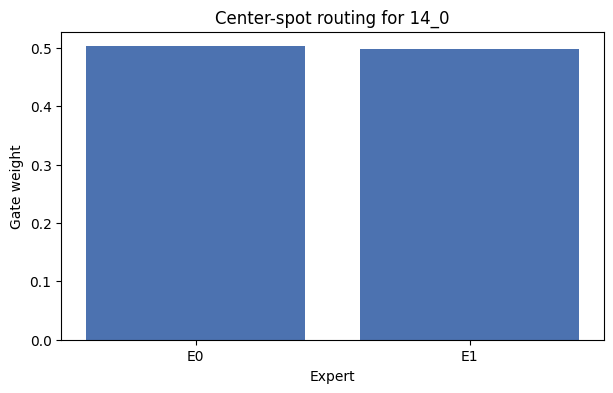

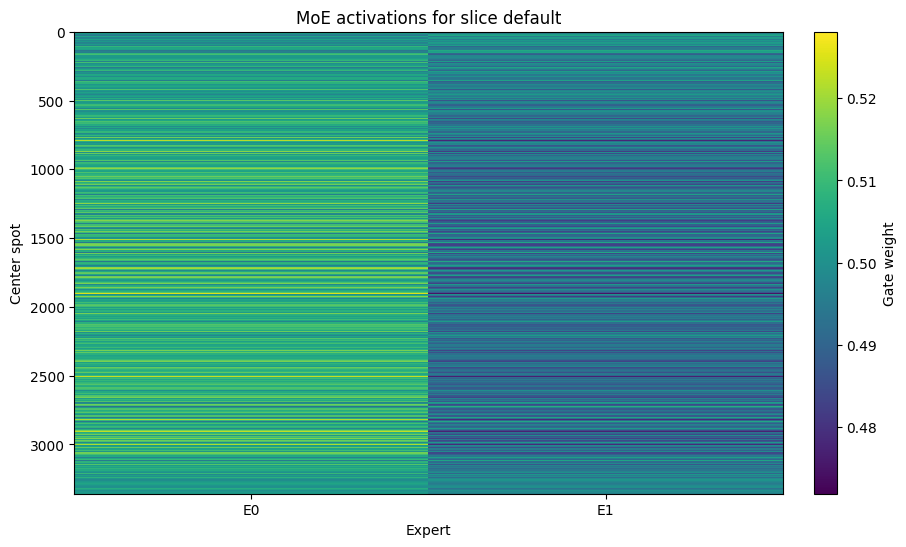

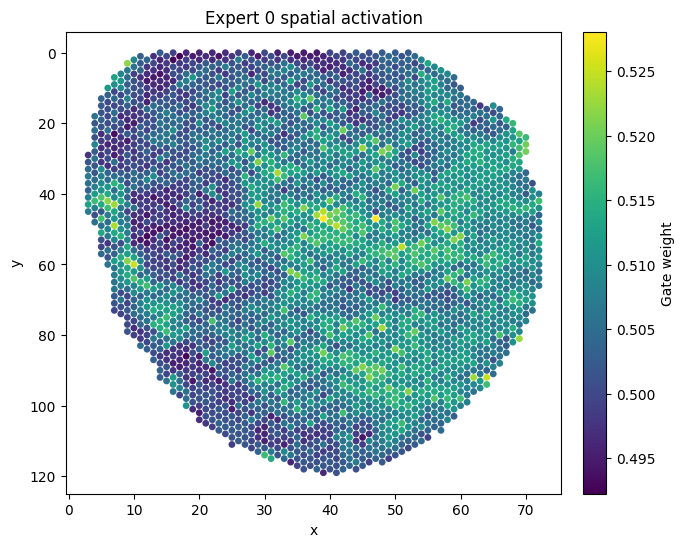

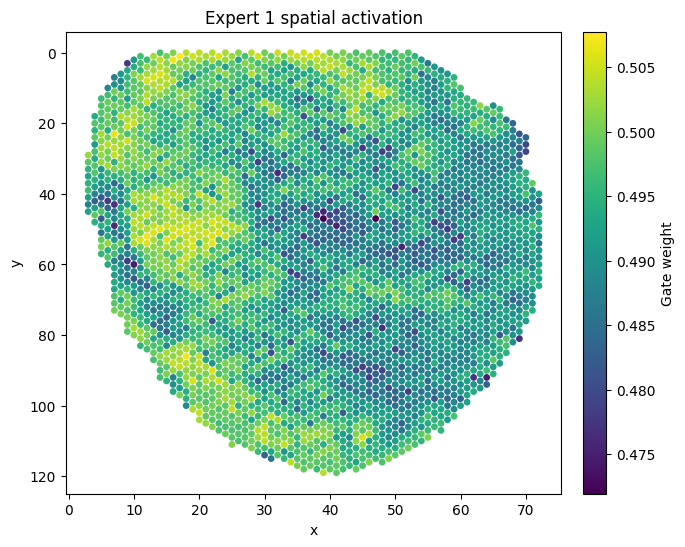

In [31]:
from utils.moe_analysis import (
    analyze_moe_routing,
    plot_center_spot_activation_bar,
    plot_expert_spatial_heatmap,
    plot_slice_activation_heatmap,
    save_moe_analysis_tables,
)

moe_results = analyze_moe_routing(
    model=model,
    dataloader=testloader,
    device=device,
    include_images=False,
    include_cell_information=False,
    include_predictions=False,
    include_targets=True,
)

activation_frame = moe_results["activation_frame"]

print("Overall MoE metrics:")
print(moe_results["overall"])
display(moe_results["expert_summary"])
if not moe_results["slice_summary"].empty:
    display(moe_results["slice_summary"])
if not moe_results["region_summary"].empty:
    display(moe_results["region_summary"])

display(activation_frame.head())
plot_center_spot_activation_bar(activation_frame, row_index=0);

if activation_frame["x"].notna().any() and activation_frame["y"].notna().any():
    first_slice = activation_frame["slice_id"].dropna().iloc[0]
    plot_slice_activation_heatmap(activation_frame, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=0, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=1, slice_id=first_slice);



else:
    print(
        "Spatial coordinates were not recovered from the sample ids. "
        "Pass `sample_metadata_resolver` to `analyze_moe_routing(...)` if you want spatial heatmaps."
    )

# Optional: save the analysis tables to disk.
# save_moe_analysis_tables(moe_results, output_dir="./moe_analysis")

